In [1]:
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
con = duckdb.connect(str(ROOT / "data" / "openag.duckdb"), read_only=True)
panel = con.sql('SELECT * FROM panel ORDER BY "Date"').df()
con.close()
panel["Date"] = pd.to_datetime(panel["Date"]).astype("datetime64[ns]")
panel = panel.set_index("Date")
print(panel.shape, "·", panel.index.min().date(), "→", panel.index.max().date())
print(list(panel.columns))

(2512, 11) · 2016-06-06 → 2026-06-05
['Close', 'log_ret', 'rolling_vol', 'spec_net', 'spec_net_pct_oi', 'drought_stress', 'usd_broad', 'treasury_10y', 'wti_crude', 'corn_ending_stocks_mmt', 'regime']


In [2]:
H = 30  # forecast horizon, trading days

df = panel.copy()

# target: 30-day-ahead log return (stationary; level reconstructed later)
df["y"] = np.log(df["Close"].shift(-H)) - np.log(df["Close"])

# vanilla features — price & calendar ONLY (regime/exogenous cols held for Week 5)
for lag in [1, 5, 10, 21, 63]:
    df[f"ret_{lag}"] = np.log(df["Close"]) - np.log(df["Close"].shift(lag))
df["vol_21"] = df["rolling_vol"]
doy = df.index.dayofyear
df["sin_doy"] = np.sin(2 * np.pi * doy / 365.25)
df["cos_doy"] = np.cos(2 * np.pi * doy / 365.25)

FEATURES = ["ret_1", "ret_5", "ret_10", "ret_21", "ret_63", "vol_21", "sin_doy", "cos_doy"]

model_df = df.dropna(subset=FEATURES + ["y"])
print(model_df.shape, "·", model_df.index.min().date(), "→", model_df.index.max().date())
print("features:", FEATURES)
print("target  : 30-day forward log return  (mean", round(model_df["y"].mean(), 4),
      "· std", round(model_df["y"].std(), 4), ")")

(2419, 20) · 2016-09-02 → 2026-04-23
features: ['ret_1', 'ret_5', 'ret_10', 'ret_21', 'ret_63', 'vol_21', 'sin_doy', 'cos_doy']
target  : 30-day forward log return  (mean 0.0038 · std 0.0866 )


In [3]:
# walk-forward harness (30-day embargo) + random-walk baseline

def walk_forward_folds(idx, oos_start, step=21, embargo=H, min_train=250):
    """Expanding-window folds; train target windows never reach the test region (embargo=H)."""
    idx = pd.DatetimeIndex(idx)
    start = int(np.searchsorted(idx, pd.Timestamp(oos_start)))
    folds = []
    for origin in range(start, len(idx), step):
        train_pos = np.arange(0, origin - embargo)
        test_pos = np.arange(origin, min(origin + step, len(idx)))
        if len(train_pos) >= min_train and len(test_pos) > 0:
            folds.append((train_pos, test_pos))
    return folds


def evaluate(folds, data, features, fit_predict):
    """Run fit_predict(train_df, test_df, features) -> yhat across folds; stack OOS predictions."""
    parts = []
    for train_pos, test_pos in folds:
        tr, te = data.iloc[train_pos], data.iloc[test_pos]
        yhat = fit_predict(tr, te, features)
        parts.append(pd.DataFrame({"y": te["y"].to_numpy(), "yhat": np.asarray(yhat)}, index=te.index))
    return pd.concat(parts)


def report(name, oos):
    err = oos["y"] - oos["yhat"]
    rmse = np.sqrt((err ** 2).mean())
    mae = err.abs().mean()
    print(f"{name:<16} OOS={len(oos):>5}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return rmse


def fit_predict_rw(tr, te, features):
    return np.zeros(len(te))  # random walk: predict zero 30-day return


folds = walk_forward_folds(model_df.index, oos_start="2020-01-01")
print(f"{len(folds)} folds · OOS {model_df.index[folds[0][1][0]].date()} → {model_df.index[-1].date()}")

oos_rw = evaluate(folds, model_df, FEATURES, fit_predict_rw)
report("random walk", oos_rw)

oos_rw = oos_rw.assign(year=oos_rw.index.year)
per_year = oos_rw.groupby("year").apply(
    lambda d: np.sqrt(((d["y"] - d["yhat"]) ** 2).mean()), include_groups=False
)
print("\nRW RMSE by year:")
print(per_year.round(4).to_string())

76 folds · OOS 2020-01-02 → 2026-04-23
random walk      OOS= 1586  RMSE=0.0952  MAE=0.0736

RW RMSE by year:
year
2020    0.1116
2021    0.1165
2022    0.1112
2023    0.0897
2024    0.0776
2025    0.0634
2026    0.0436


In [4]:
# seasonal naïve + AR(1), scored vs the random-walk floor
model_df["y_seasonal"] = model_df["y"].shift(252)   # 30-day return from ~1 year ago
model_df["y_lag30"] = model_df["y"].shift(30)        # prior (non-overlapping) 30-day return


def fit_predict_seasonal(tr, te, features):
    return te["y_seasonal"].fillna(0.0).to_numpy()


def fit_predict_ar1(tr, te, features):
    trc = tr.dropna(subset=["y_lag30"])
    X = np.c_[np.ones(len(trc)), trc["y_lag30"].to_numpy()]
    beta, *_ = np.linalg.lstsq(X, trc["y"].to_numpy(), rcond=None)
    Xte = np.c_[np.ones(len(te)), te["y_lag30"].fillna(0.0).to_numpy()]
    return Xte @ beta


baselines = {
    "random walk": fit_predict_rw,
    "seasonal naive": fit_predict_seasonal,
    "AR(1)": fit_predict_ar1,
}

oos_store = {name: evaluate(folds, model_df, FEATURES, fp) for name, fp in baselines.items()}

results = {}
for name, oos in oos_store.items():
    err = oos["y"] - oos["yhat"]
    results[name] = {"RMSE": np.sqrt((err ** 2).mean()), "MAE": err.abs().mean()}

res = pd.DataFrame(results).T
res["skill_vs_RW"] = 1 - res["RMSE"] / res.loc["random walk", "RMSE"]
print(res.round(4).to_string())

py = pd.DataFrame({
    name: oos.assign(year=oos.index.year).groupby("year").apply(
        lambda d: np.sqrt(((d["y"] - d["yhat"]) ** 2).mean()), include_groups=False)
    for name, oos in oos_store.items()
})
print("\nRMSE by year:")
print(py.round(4).to_string())

                  RMSE     MAE  skill_vs_RW
random walk     0.0952  0.0736       0.0000
seasonal naive  0.1199  0.0943      -0.2603
AR(1)           0.0989  0.0764      -0.0392

RMSE by year:
      random walk  seasonal naive   AR(1)
year                                     
2020       0.1116          0.1315  0.1211
2021       0.1165          0.1645  0.1197
2022       0.1112          0.1173  0.1126
2023       0.0897          0.1194  0.0957
2024       0.0776          0.1004  0.0778
2025       0.0634          0.0749  0.0649
2026       0.0436          0.0918  0.0423


In [5]:
import xgboost as xgb


def fit_predict_xgb(tr, te, features):
    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=0, n_jobs=-1,
    )
    model.fit(tr[features], tr["y"])
    return model.predict(te[features])


models = {
    "random walk": fit_predict_rw,
    "seasonal naive": fit_predict_seasonal,
    "AR(1)": fit_predict_ar1,
    "vanilla XGB": fit_predict_xgb,
}

oos_store = {name: evaluate(folds, model_df, FEATURES, fp) for name, fp in models.items()}

results = {}
for name, oos in oos_store.items():
    err = oos["y"] - oos["yhat"]
    results[name] = {"RMSE": np.sqrt((err ** 2).mean()), "MAE": err.abs().mean()}
res = pd.DataFrame(results).T
res["skill_vs_RW"] = 1 - res["RMSE"] / res.loc["random walk", "RMSE"]
print(res.round(4).to_string())

py = pd.DataFrame({
    name: oos.assign(year=oos.index.year).groupby("year").apply(
        lambda d: np.sqrt(((d["y"] - d["yhat"]) ** 2).mean()), include_groups=False)
    for name, oos in oos_store.items()
})
print("\nRMSE by year:")
print(py.round(4).to_string())

                  RMSE     MAE  skill_vs_RW
random walk     0.0952  0.0736       0.0000
seasonal naive  0.1199  0.0943      -0.2603
AR(1)           0.0989  0.0764      -0.0392
vanilla XGB     0.0980  0.0776      -0.0303

RMSE by year:
      random walk  seasonal naive   AR(1)  vanilla XGB
year                                                  
2020       0.1116          0.1315  0.1211       0.1332
2021       0.1165          0.1645  0.1197       0.1072
2022       0.1112          0.1173  0.1126       0.1171
2023       0.0897          0.1194  0.0957       0.0786
2024       0.0776          0.1004  0.0778       0.0589
2025       0.0634          0.0749  0.0649       0.0826
2026       0.0436          0.0918  0.0423       0.0614


saved → c:\Users\siddh\Downloads\OPEN-AG\openag-risk-twin\notebooks\figures\02_xgb_vs_rw_by_year.png


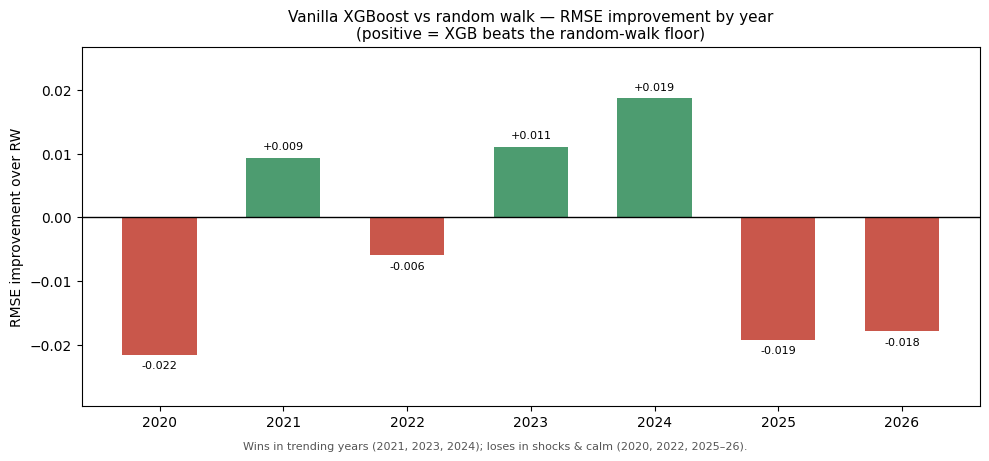

In [6]:
# per-year XGB-vs-RW figure for the README
FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

improve = py["random walk"] - py["vanilla XGB"]          # positive = XGB beats RW
colors = ["#2e8b57" if v > 0 else "#c0392b" for v in improve]
years = improve.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(years, improve.values, color=colors, alpha=0.85, width=0.6)
ax.axhline(0, color="black", lw=1)
for x, v in zip(years, improve.values):
    ax.text(x, v + (0.001 if v >= 0 else -0.001), f"{v:+.3f}",
            ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
ax.set_title("Vanilla XGBoost vs random walk — RMSE improvement by year\n(positive = XGB beats the random-walk floor)", fontsize=11)
ax.set_ylabel("RMSE improvement over RW")
ax.margins(y=0.20)
fig.text(0.5, -0.01,
         "Wins in trending years (2021, 2023, 2024); loses in shocks & calm (2020, 2022, 2025–26).",
         ha="center", fontsize=8, color="#555")

plt.tight_layout()
out = FIG_DIR / "02_xgb_vs_rw_by_year.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("saved →", out)
plt.show()